In [1]:
import os
import sys
from pathlib import Path

#export PYTHONPATH=$PYTHONPATH:/home/nishi/local/git-download/lerobot/src
# パスを通す（お使いの環境に合わせて絶対パスに書き換えてください）
# git clone をした、パスを使ってください。
lerobot_path = "/home/nishi/local/git-download/lerobot"
sys.path.append(os.path.join(lerobot_path, "src"))

from lerobot.configs.train import TrainPipelineConfig
from lerobot.scripts.lerobot_train import train
from lerobot.configs.policies import PreTrainedConfig

import torch.nn.functional as F

#batch_size=2
#batch_size=4
batch_size=8


In [2]:
import matplotlib.pyplot as plt
import japanize_matplotlib # これを足すだけで日本語が使えるようになります
import torch

from lerobot.datasets.lerobot_dataset import LeRobotDataset
# データセットを直接読み込む
#dataset = LeRobotDataset("lerobot/aloha_static_pingpong_test")

DATASET_ID = "lerobot/aloha_sim_transfer_cube_human"
# データセットを作るコードを探して、delta_timestamps を追加します
dataset = LeRobotDataset(
    DATASET_ID,
    delta_timestamps={"action": [i/50 for i in range(100)]} # 50Hzなので /50
)

if False:
    # 最初の1コマ（1ステップ分）をのぞき見
    frame = dataset[0]
    #print('frame.keys():',frame.keys())
    # model inputs は、(3,480,640) で、色順は、RGB です。
    # plt.imshow()は、デフォルトでRGB（赤・緑・青）の順序 なので、 model の入力も RGB のままです。
    # 2. 画像を表示してみる (PyTorchの [C, H, W] 形式を pillow.show 用の [H, W, C] に変換)
    img = frame["observation.images.top"].permute(1, 2, 0)
    print('img.shape:',img.shape)  # img.shape: torch.Size([480, 640, 3]) これは、あくまで、pillow 用です。
    plt.imshow(img)
    plt.title("AIが見ている画像 (cam_high)")
    plt.show()

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [3]:
from ResizeWithPadTensor import ResizeWithPadTensor
resize_main=ResizeWithPadTensor()

In [4]:
from torchvision import transforms
# 1. 特訓メニュー（オーグメンテーション）の定義
train_transform = transforms.Compose([
    # --------------------------------
    # ResNet18 backbone 用
    # --------------------------------
    #transforms.Resize((224,224)),
    ResizeWithPadTensor((224,224)),
    # augmentation
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=5,
            sigma=(0.1, 1.0)
        )
    ], p=0.2),
    # normalize
    transforms.Normalize(
        mean=[0.485,0.456,0.406], # 赤・緑・青の平均値
        std=[0.229,0.224,0.225]   # 標準偏差
    )
])


In [5]:
idx=0

img.shape: torch.Size([480, 640, 3])


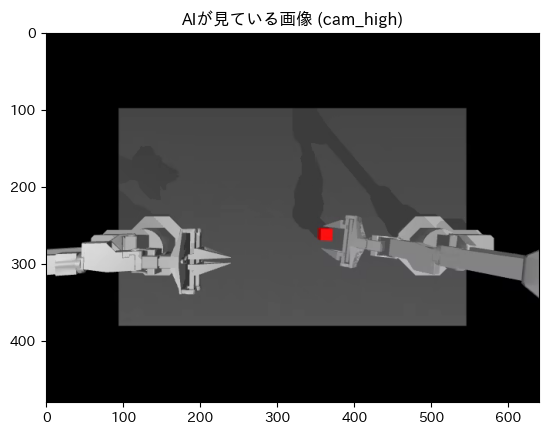

img_raw.shape: torch.Size([3, 480, 640])
img.shape: torch.Size([224, 224, 3])


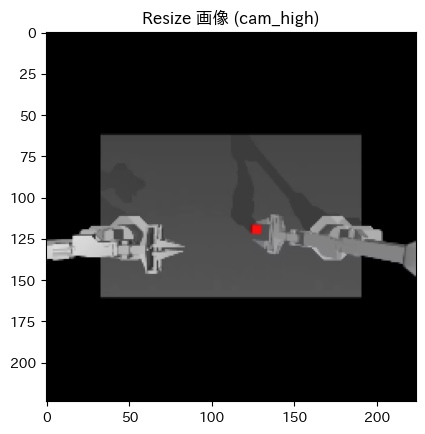

img_batch.shape: torch.Size([1, 3, 480, 640])
img_augmented.shape: torch.Size([224, 224, 3])


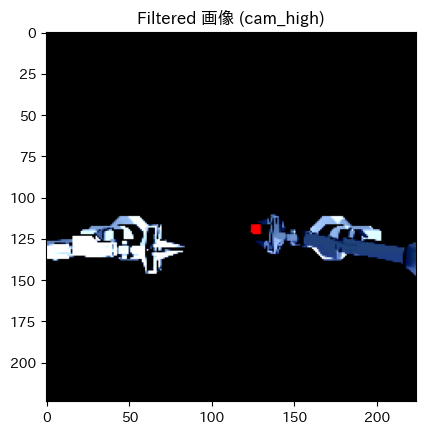

In [9]:
frame = dataset[idx]
img = frame["observation.images.top"].permute(1, 2, 0)
print('img.shape:',img.shape)  # img.shape: torch.Size([480, 640, 3]) これは、あくまで、pillow 用です。
plt.imshow(img)
plt.title("AIが見ている画像 (cam_high)")
plt.show()

#print('frame.keys():',frame.keys())
# model inputs は、(3,480,640) で、色順は、RGB です。
# plt.imshow()は、デフォルトでRGB（赤・緑・青）の順序 なので、 model の入力も RGB のままです。
# 2. 画像を表示してみる (PyTorchの [C, H, W] 形式を pillow.show 用の [H, W, C] に変換)
#img = frame["observation.images.top"].permute(1, 2, 0)
#print('img.shape:',img.shape)  # img.shape: torch.Size([480, 640, 3]) これは、あくまで、pillow 用です。
img_raw = frame["observation.images.top"]
print('img_raw.shape:',img_raw.shape)
#print('img_raw.type:',img_raw.type)

# [B,C,H,W] に変換する。
img=resize_main(img_raw.unsqueeze(0)).squeeze(0).permute(1, 2, 0)
print('img.shape:',img.shape)
plt.imshow(img)
plt.title("Resize 画像 (cam_high)")
plt.show()

img_raw = frame["observation.images.top"]
img_batch = img_raw.unsqueeze(0)
print('img_batch.shape:',img_batch.shape)
img_augmented = train_transform(img_batch).squeeze(0).permute(1, 2, 0)
print('img_augmented.shape:',img_augmented.shape)

plt.imshow(img_augmented)
plt.title("Filtered 画像 (cam_high)")
plt.show()
idx+=50